In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [5]:
df.describe()

,job_posted_date,salary_year_avg,salary_hour_avg
count,785741,22003.000000,10662.000000
mean,2023-06-25 16:02:11.860247,123286.274072,47.016598
min,2023-01-01 00:00:04,15000.000000,8.000000
25%,2023-03-20 10:05:48,90000.000000,27.500000
50%,2023-06-29 06:11:38,115000.000000,45.980000
75%,2023-09-27 01:01:16,150000.000000,61.159996
max,2023-12-31 23:59:58,960000.000000,391.000000
std,NaN,48312.449482,21.890738


In [6]:
df_India = df[df['job_country'] == 'India']
df_India

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,"[powershell, python, sql, mysql, sql server, d...","{'cloud': ['databricks', 'azure'], 'databases'..."
19,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,NaN,NaN,NaN,Bitwise Solutions,"[r, sql, python, scala, java, c++, hadoop, tab...","{'analyst_tools': ['tableau'], 'libraries': ['..."
29,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Exusia,Full-time,False,India,2023-03-26 13:16:20,False,False,India,NaN,NaN,NaN,Exusia,NaN,NaN
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,NaN,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'..."
42,Senior Data Engineer,"Senior Data Engineer(Python)-1563,1637&1633","Chennai, Tamil Nadu, India",via HR Software For Growing Businesses | Fresh...,Full-time,False,India,2023-11-10 13:30:41,True,False,India,NaN,NaN,NaN,CESIT,"[python, sql, aws, pyspark, docker, jira]","{'async': ['jira'], 'cloud': ['aws'], 'librari..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785712,Data Engineer,India - Collections Analyst II,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Varite India Private Limited,"[excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']}"
785715,Data Analyst,Amul Careers 2023 - Apply Online - Data Analys...,India,melalui Jobsleworld - Jobs In India - Job Vaca...,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Amul,NaN,NaN
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,CompuGroup Medical,"[c#, sql]","{'programming': ['c#', 'sql']}"
785718,Business Analyst,Senior Performance QA Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Diebold Nixdorf,NaN,NaN


In [7]:
df_India['job_title_short'].value_counts()


job_title_short
Data Engineer                19062
Data Scientist               13279
Data Analyst                  6121
Senior Data Engineer          4353
Senior Data Scientist         2486
Business Analyst              1887
Software Engineer             1795
Senior Data Analyst           1083
Machine Learning Engineer      671
Cloud Engineer                 351
Name: count, dtype: int64

In [8]:
top_3 = df_India['job_title_short'].value_counts().head(3).index

In [9]:
top_3 = top_3.to_list()

In [10]:
df_India_exploaded = df_India.explode('job_skills')
df_India_exploaded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,powershell,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,python,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,sql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,mysql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,sql server,"{'cloud': ['databricks', 'azure'], 'databases'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,CompuGroup Medical,c#,"{'programming': ['c#', 'sql']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,CompuGroup Medical,sql,"{'programming': ['c#', 'sql']}"
785718,Business Analyst,Senior Performance QA Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:28,False,False,India,NaN,NaN,NaN,Diebold Nixdorf,NaN,NaN
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


In [11]:
df_India_exploaded = df_India_exploaded.groupby(['job_title_short','job_skills']).size().reset_index(name = 'skill_counts')
df_India_exploaded.sort_values(by = 'skill_counts' , ascending=False , inplace=True)


In [12]:
df_India_exploaded


,job_title_short,job_skills,skill_counts
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
25,Business Analyst,dart,1
27,Business Analyst,datarobot,1
30,Business Analyst,django,1
32,Business Analyst,drupal,1


In [13]:
job_title = df_India_exploaded['job_title_short'].unique().tolist()

In [14]:
job_title = job_title[:3]
job_title

['Data Engineer', 'Data Scientist', 'Data Analyst']

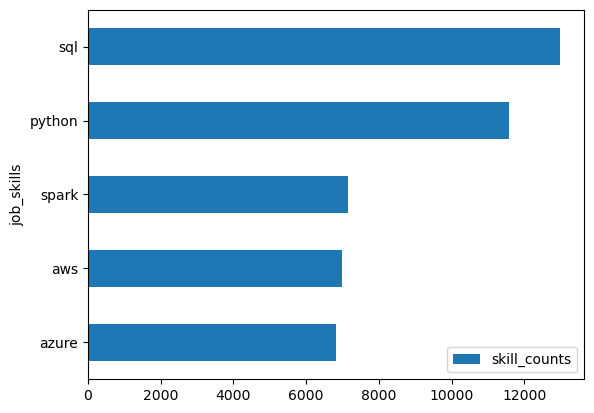

In [15]:
df_plot_example = df_India_exploaded[df_India_exploaded['job_title_short'] == job_title[0]].head(5)
df_plot_example = df_plot_example.plot(kind = 'barh' , x = 'job_skills' , y = 'skill_counts')
df_plot_example.invert_yaxis()


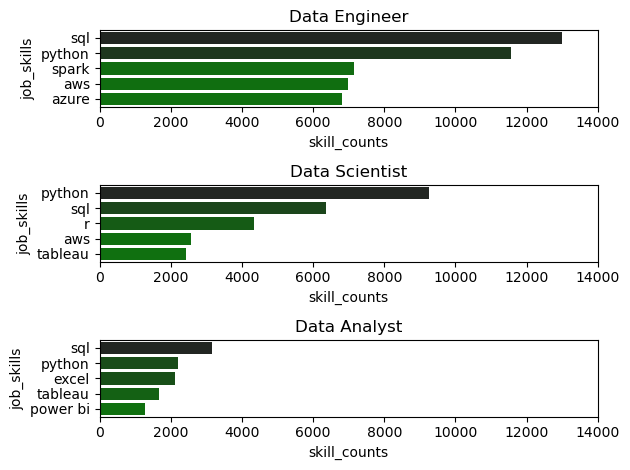

In [16]:
fig,ax = plt.subplots(3,1)
for i,title in enumerate(job_title):
    df_plot_example = df_India_exploaded[df_India_exploaded['job_title_short'] == title].head(5)
    #df_plot_example.plot(kind = 'barh' , x = 'job_skills' , y = 'skill_counts' , ax = ax[i] , legend = False , title = title)
    sns.barplot(data = df_plot_example ,  x = 'skill_counts' , y = 'job_skills'  , ax = ax[i] , legend = False ,  hue = 'skill_counts' , palette = 'dark:g_r' )
    ax[i].set_title(title)
    #ax[i].invert_yaxis() ---> here its of no use since seaborn already has inbuilt y_invert in it

    ax[i].set_xlim(0,14000)
fig.tight_layout()
    
   


In [17]:
#in above we can also represent the percentage of each of the bar 
df_count = df_India['job_title_short'].value_counts().reset_index(name = 'job_count')
df_count


,job_title_short,job_count
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


In [18]:
df_merged = pd.merge(df_India_exploaded , df_count , on = 'job_title_short')

In [19]:
df_merged

,job_title_short,job_skills,skill_counts,job_count
0,Data Engineer,sql,12993,19062
1,Data Engineer,python,11568,19062
2,Data Scientist,python,9248,13279
3,Data Engineer,spark,7157,19062
4,Data Engineer,aws,6993,19062
...,...,...,...,...
1684,Business Analyst,dart,1,1887
1685,Business Analyst,datarobot,1,1887
1686,Business Analyst,django,1,1887
1687,Business Analyst,drupal,1,1887


In [20]:
df_merged['job_skill_percent'] = (df_merged['skill_counts'] / df_merged['job_count']) * 100

In [21]:
df_merged

,job_title_short,job_skills,skill_counts,job_count,job_skill_percent
0,Data Engineer,sql,12993,19062,68.161788
1,Data Engineer,python,11568,19062,60.686182
2,Data Scientist,python,9248,13279,69.643798
3,Data Engineer,spark,7157,19062,37.545903
4,Data Engineer,aws,6993,19062,36.685552
...,...,...,...,...,...
1684,Business Analyst,dart,1,1887,0.052994
1685,Business Analyst,datarobot,1,1887,0.052994
1686,Business Analyst,django,1,1887,0.052994
1687,Business Analyst,drupal,1,1887,0.052994


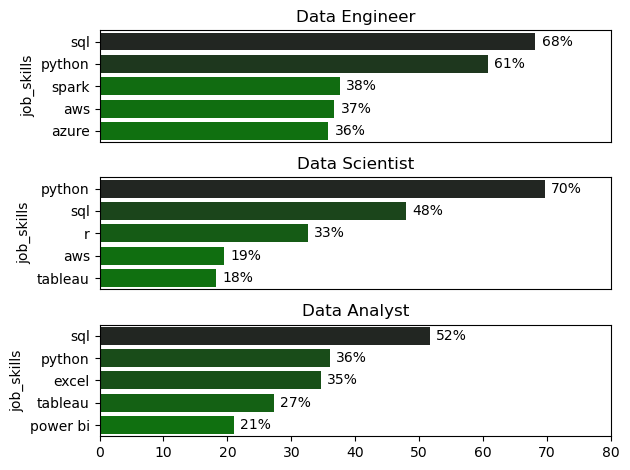

In [22]:
fig,ax = plt.subplots(3,1)
for i,title in enumerate(job_title):
    df_plot_example = df_merged[df_merged['job_title_short'] == title].head(5)
    #df_plot_example.plot(kind = 'barh' , x = 'job_skills' , y = 'skill_counts' , ax = ax[i] , legend = False , title = title)
    sns.barplot(data = df_plot_example ,  x = 'job_skill_percent' , y = 'job_skills'  , ax = ax[i] ,legend = False ,  hue = 'job_skill_percent' , palette = 'dark:g_r' )
    ax[i].set_title(title)
    #ax[i].invert_yaxis() ---> here its of no use since seaborn already has inbuilt y_invert in it
    ax[i].set_xlim(0,80)
    ax[i].set_xlabel('')
    for p in ax[i].patches:
      width = p.get_width()
      y = p.get_y() + p.get_height() / 2

      ax[i].text(
        width + 1,           # little space to the right of bar
        y,                   # vertical center of bar
        f'{width:.0f}%',     # format value
        va='center'
      
      )
    if(i < len(job_title) - 1):
       ax[i].set_xticks([])
         
 
fig.tight_layout()
    